In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.nn import functional as F

import tiktoken

nn.Embedding vs nn.Linear

In [2]:
vocab_size = 5000
embed_dim = int(vocab_size**0.5) 
print(f"Vocabulary size: {vocab_size}, embedding dimension: {embed_dim}")

Vocabulary size: 5000, embedding dimension: 70


In [ ]:
emb_layer = nn.Embedding(vocab_size, embed_dim) # input: (batch_size, context_size) -> output: (batch_size, context_size, embed_dim)
lin_layer = nn.Linear(embed_dim, vocab_size) # input: (batch_size, context_size, embed_dim) -> output: (batch_size, context_size, vocab_size)

# they have the same number of parameters, but the embedding layer has much fewer FLOPs since it only looks up values instead of doing a full matrix multiplication
# FLOPs stands for "floating point operations" and is a common way to measure the computational cost of a model.
emb_layer.weight.shape, lin_layer.weight.shape

(torch.Size([5000, 70]), torch.Size([5000, 70]))

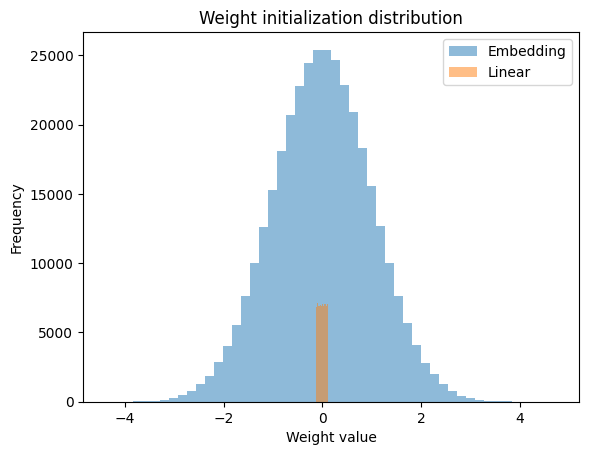

In [ ]:
# histogram of weights initialization for both layers
plt.hist(emb_layer.weight.detach().numpy().flatten(), bins=50, alpha=0.5, label="Embedding")
plt.hist(lin_layer.weight.detach().numpy().flatten(), bins=50, alpha=0.5, label="Linear")
plt.legend()
plt.title("Weight initialization distribution")
plt.xlabel("Weight value")
plt.ylabel("Frequency")
plt.show()

# the embedding layer has a much narrower distribution of weights, which is a common initialization strategy for embeddings to help with training stability.
# the linear layer has a wider distribution, which is typical for layers that will be trained with backpropagation to learn complex patterns.

In [ ]:
# check the standard deviation and bounds of the weights for both layers to see if they match the expected Kaiming uniform initialization
kaiming_expected_std = np.sqrt(1/ embed_dim)/np.sqrt(3) # Kaiming uniform initialization has a range of [-sqrt(6/fan_in), sqrt(6/fan_in)], so the std is sqrt(1/fan_in)/sqrt(3)
lin_layer_std = lin_layer.weight.detach().numpy().std()
emb_layer_std = emb_layer.weight.detach().numpy().std()
print(f"Expected Kaiming std: {kaiming_expected_std:.4f}, Linear layer std: {lin_layer_std:.4f}, Embedding layer std: {emb_layer_std:.4f}")

kaiming_expected_bounds = np.sqrt(1/embed_dim)
lin_layer_bounds = (lin_layer.weight.detach().min().item(), lin_layer.weight.detach().max().item())
emb_layer_bounds = (emb_layer.weight.detach().min().item(), emb_layer.weight.detach().max().item())
print(f"Expected Kaiming bounds: ±{kaiming_expected_bounds:.4f}, Linear layer bounds: {lin_layer_bounds}, Embedding layer bounds: {emb_layer_bounds}")

Expected Kaiming std: 0.0690, Linear layer std: 0.0689, Embedding layer std: 1.0003
Expected Kaiming bounds: ±0.1195, Linear layer bounds: (-0.11952172219753265, 0.11952253431081772), Embedding layer bounds: (-4.388163089752197, 4.75014066696167)


In [ ]:
# repeat for Xavier initialization
xavier_expected_std = np.sqrt(2/ (embed_dim + vocab_size)) # Xavier initialization has a range of [-sqrt(6/(fan_in + fan_out)), sqrt(6/(fan_in + fan_out))], so the std is sqrt(2/(fan_in + fan_out))
lin_layer_xavier_std = lin_layer.weight.detach().numpy().std()
emb_layer_xavier_std = emb_layer.weight.detach().numpy().std()
print(f"Expected Xavier std: {xavier_expected_std:.4f}, Linear layer std: {lin_layer_xavier_std:.4f}, Embedding layer std: {emb_layer_xavier_std:.4f}")

Expected Xavier std: 0.0199, Linear layer std: 0.0689, Embedding layer std: 1.0003


Activation Functions

In [28]:
from scipy.special import erf

def relu(x):
    y = x * (x>=0)
    return y
    
def gelu_exact(x):
    y = x/2*(1 + erf(x/np.sqrt(2)))
    return y

def gelu_approx(x):
    y = x/2 * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715*x**3)))
    return y

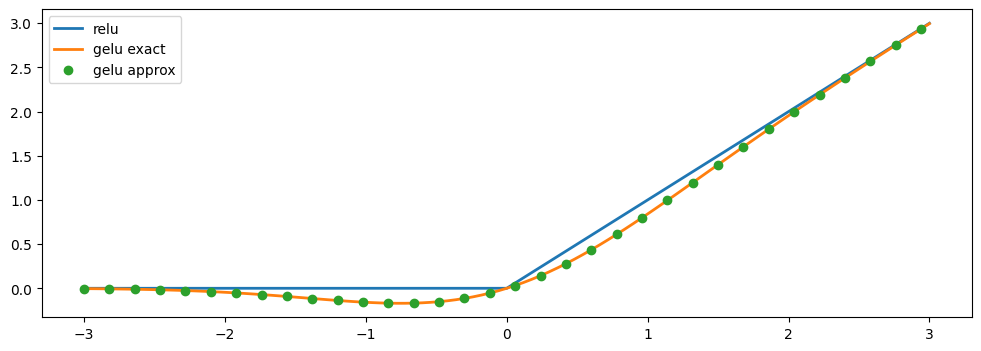

In [36]:
x = np.linspace(-3, 3, 101)
relu_y = relu(x)
gelu_exact_y = gelu_exact(x)
gelu_approx_y = gelu_approx(x)

plt.figure(figsize=(12, 4))
plt.plot(x, relu_y, linewidth=2, label="relu")
plt.plot(x, gelu_exact_y, linewidth=2, label="gelu exact")
plt.plot(x[::3], gelu_approx_y[::3], "o", label="gelu approx")
plt.legend()
plt.show()

In [ ]:
# now using pytorch
x = torch.linspace(-3, 3, 333)
dx = x[1:] - x[:-1]

relu_torch = F.relu(x)
gelu_torch = F.gelu(x)

d_relu = torch.diff(relu_torch) / dx
d_gelu = torch.diff(gelu_torch) / dx

fig, axs = plt.subplots(2, 1, figsize=(12, 10))
